# MOOC Assignment Block 1

In this assignment we want to estimate the parameters to approximate a rating curve. We do so by using the RWM (Random Walk Metropolis) Algorithm.

In [78]:
# First we load the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy.random as rnd
from scipy.stats import multivariate_normal as mvn

# Now we load the dataset from the txt file
data = pd.read_csv('rc_Q_V.txt')
length = data.shape[0]
# Create error array
error_array = []
data

,H,Q
0,46.8,2039.0
1,45.3,1557.0
2,40.1,1291.7
3,40.1,1298.2
4,56.9,2639.5
5,29.9,420.7
6,29.9,433.5
7,32.3,559.0
8,32.3,501.6
9,23.7,266.6


Our overall goal is to get a good approximative rating curve. For this, we formulate a Bayesian Inverse Problem. The core idea is to obtain a posterior distribution. This can be computed straight forward in our setup. Before deriving and implementing this, let's quickly remark why this ansatz might be helpful. Given a posterior distribution explaining well our observations, we can sample from it using a Monte Carlo Markov Chain (MCMC) ansatz. Our implementation of the theory of MCMC is the so-called Random Walk Metropolis Algorithm (RWMA). The idea behind MCMC is straight forward: Markov Chains (MC) converge under certain conditions to a so-called stationary distribution, which is again under some conditions unique. The conditions on the MC are:
1. Irreducibility, i.e. we reach each point in a finite amount of steps
2. Detailed balance condition is fullfilled
3. The MC is aperiodic
4. Harris recurrence, i.e the probability to visit a set of states infinitely often is one

If these technical conditions are fullfilled, a unique stationary distribution exists. Now, we want to find a MC such that it has the stationary distribution approximating our posterior. With this, we can sample from the stationary distribution. We measure the quality of our samples by the Effective Sample Size (ESS) and Auto-correlation, which are closely related.
The RWMA follows this approach: At each time step, a new candidate for the chain is proposed as follows:
You are given a proposal distribution from which you sample from. Next, you set the new candidate as the current state plus the sample and compute the acceptance probability. Then you choose randomly whether this candidate is accepted or not. You iterate this algortihm over the components of the MC.

With this general overview and motivation we can go through the exercise. First, we compute our posterior distribution parameters.

Let $\bold{q}$ denote the flow and $\bold{h}$ the height of the water flow. A rating curve gives the relation between both in general. We assume that the rating curve has an exponential form, i.e. we apply the log to get a linear problem and relation:
$$ \log(\bold{q}) = A x + \eta$$
Here, $\eta$ is a noise which follows a Gaussian distribution $N(0,\Gamma)$, where $\Gamma = diag(0.03 \bold{q})$. The matrix a is given by
$$
A =
\begin{pmatrix}
1 & \log(h_1) \\
1 & \log(h_2) \\
\vdots & \vdots \\
1 & \log(h_{n_d})
\end{pmatrix}.
$$

Using Bayes theorem and the fact that our noise is Gaussian, we can explicitly compute the likelihood. Assuming furthermore a Gaussian prior $\rho_0$ ~ $ N(m_0, \Sigma_0)$ we can carry out the computations and obtain that the posterior follows a Gaussian as well: $N(m,\Sigma)$ with
$$ m = m_0 + \Sigma_0 A^{T} \left( \Gamma + A \Sigma_0 A^{T} \right)^{-1} (log(q) - Am_0),$$
$$ \Sigma = \Sigma_0 - \Sigma_0 A^{T} \left( \Gamma + A \Sigma_0 A^{T} \right)^{-1} A \Sigma_0.$$

In [79]:
# Get height and flow from the data
q = data['Q'].values
h = data['H'].values
# Define prior mean and covariance
m0 = np.array([0, 0])
Sigma0 = np.array([[10, 0], [0, 10]])
# Define the noise
Gamma = np.diag(0.03 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 2))
A[:, 0] = 1
A[:, 1] = np.log(h)
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
def posterior(m0, Sigma0, A, Gamma, y):
    posterior_mean = m0 + Sigma0 @ A.T @ np.linalg.inv(Gamma + A @ Sigma0 @ A.T) @ (y - A @ m0)
    posterior_cov = Sigma0 - Sigma0 @ A.T @ np.linalg.inv(Gamma + A @ Sigma0 @ A.T) @ A @ Sigma0
    return posterior_mean, posterior_cov

posterior_mean, posterior_cov = posterior(m0, Sigma0, A, Gamma, y)
# Print the results
print("Posterior Mean:\n", posterior_mean)
print("Posterior Covariance:\n", posterior_cov)

Posterior Mean:
 [-2.56371979  2.58257909]
Posterior Covariance:
 [[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]


In [80]:
# We write a function to compute the prior, log likelihood and product of those, i.e the posterior
def prior(m0, Sigm0, x):
    n = len(x)
    constant = 1/((2*np.pi)**(n/2)*np.linalg.det(Sigma0)**0.5)
    exponent = -0.5 * (x - m0).T @ np.linalg.inv(Sigma0) @ (x - m0)
    return constant * np.exp(exponent)

def likelihood(q,A,x,Gamma): #here we use the proportionality as deduced in the lecture
    n = len(q)
    exponent = -0.5 * (np.log(q) - A @ x).T @ np.linalg.inv(Gamma) @ (np.log(q) - A @ x)
    return np.exp(exponent)

def posterior_computation(m0,Sigma0,q,A,Gamma,x):
    factor1 = prior(m0,Sigma0,x)
    factor2 = likelihood(q,A,x,Gamma)
    return factor1 * factor2

# Best running code
def log_posterior(m0, Sigma0, q, A, Gamma,x):
    x = np.asarray(x)

    # prior (Gaussian)
    prior_term = -0.5 * (x - m0).T @ np.linalg.inv(Sigma0) @ (x - m0)

    # likelihood
    r = np.log(q) - A @ x
    likelihood_term = -0.5 * r.T @ np.linalg.inv(Gamma) @ r

    return prior_term + likelihood_term


# RWMA implementation
We now want to implement the RWMA. Recall that we aim to draw samples from a stationary distribution of a MC approximating our posterior distribution. To do so, as we discretized in time, at each time step you draw a sample from a so-called proposal distribution and add it to the current state. You compute the acceptance probability and finally accept or neglect the new candidate. The lecture states that an optimal acceptance rate is in (0.2 , 0.3). You iterate through the states. Formally:
Let $\bold{Q}$ be our proposal density, $\bold{\pi}$ be our target distribution with density $\rho$.Assume that our initial state $x_0$ is given. Then:

For j = 1,2,..
1. Draw $\epsilon$ ~ $\bold{Q}$ independently from $X_{j-1} $
2. Set $X' = X_{j-1} + \epsilon$
3. Compute the acceptance probability $\alpha(X' | X_{j-1}) := \min\{1,\frac{\rho(X')}{\rho(X_{j-1})}\}$
4. $X_j = X'$ with probability $\alpha$ otherwhise $X_j = X_{j-1}$

Acceptance rate: 0.523000
Acceptance rate: 0.542000
Acceptance rate: 0.546000
Acceptance rate: 0.551250
Acceptance rate: 0.550800
Acceptance rate: 0.554000
Acceptance rate: 0.559143
Acceptance rate: 0.555625
Acceptance rate: 0.554889
Acceptance rate: 0.555500
Acceptance rate: 0.557364
Acceptance rate: 0.555833
Acceptance rate: 0.556923
Acceptance rate: 0.558071
Acceptance rate: 0.557800
Acceptance rate: 0.558688
Acceptance rate: 0.559412
Acceptance rate: 0.560111
Acceptance rate: 0.559421
Acceptance rate: 0.559500
Acceptance rate: 0.558571
Acceptance rate: 0.557818
Acceptance rate: 0.558130
Acceptance rate: 0.558000
Acceptance rate: 0.558880
Acceptance rate: 0.558923
Acceptance rate: 0.559185
Acceptance rate: 0.559500
Acceptance rate: 0.559172
Acceptance rate: 0.559300
Acceptance rate: 0.559194
Acceptance rate: 0.559156
Acceptance rate: 0.559394
Acceptance rate: 0.559029
Acceptance rate: 0.559571
Acceptance rate: 0.559000
Acceptance rate: 0.559108
Acceptance rate: 0.559053
Acceptance r

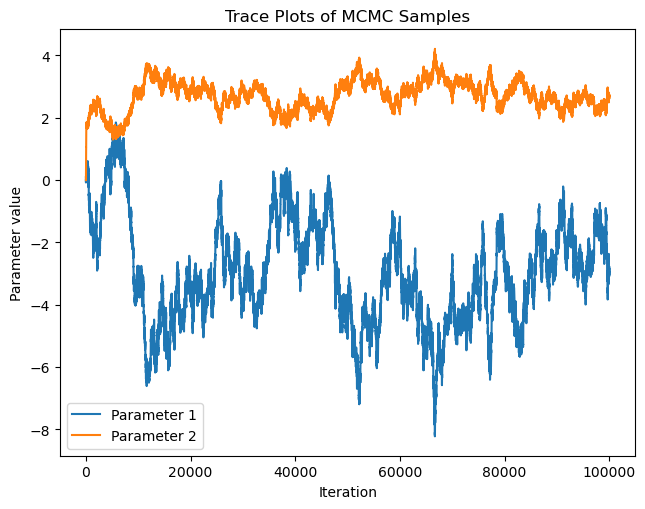

In [81]:
n = 2  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
prop_var = 0.06**2  # optimal scaling for proposal variance (Roberts et al.)

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))


def RWMA(m0, Sigma0, q, A, Gamma, N, x0):
    samples = np.empty((N, n))  # storage for generated samples
    samples[0, :] = x0  # first element in the chain is x0

    x = x0.copy()  # initialization
    logpost_x = log_posterior(m0, Sigma0, q, A, Gamma, x)
    accptd = 0  # number of accepted proposals

    for j in range(1, N):
        eps = proposal()
        x_ = x + eps
        logpost_x_ = log_posterior(m0, Sigma0, q, A, Gamma, x_)
        # Compute acceptance probability in log space for stability
        log_accpt_prob = logpost_x_ - logpost_x
        accpt_prob = np.exp(log_accpt_prob)
        accpt_prob = min(1, accpt_prob)

        if accpt_prob >= rnd.random():
            # accept
            x = x_
            logpost_x = logpost_x_
            accptd += 1

        samples[j, :] = x

        if j % 1000 == 0:
            # Print acceptance rate every 100th step
            print("Acceptance rate: %f" % (accptd/j))

    np.savetxt('samples.txt', samples)
    return samples

samples = RWMA(m0, Sigma0, q, A, Gamma, N, x0)
plt.figure()
plt.plot(range(1, N+1), samples[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples')
plt.legend()
plt.show()

In [82]:
# Comparasion of the results
sampled_mean = np.mean(samples, axis=0)
sampled_cov = np.cov(samples, rowvar=False)

print("Sampled Mean:\n", sampled_mean)
print("Sampled Covariance:\n", sampled_cov)
print("Posterior Mean:\n", posterior_mean)  
print("Posterior Covariance:\n", posterior_cov)

Sampled Mean:
 [-3.00622089  2.70643137]
Sampled Covariance:
 [[ 2.78800897 -0.7869983 ]
 [-0.7869983   0.2243534 ]]
Posterior Mean:
 [-2.56371979  2.58257909]
Posterior Covariance:
 [[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]


We see that our samples are rather close to the analytical mean. Both seem to have a high covariance. However our acceptance rate is too high, implying an inappropriate proposal variance.

We will start by determining the burn-in period and then ignore those samples. The burn-in period is the amount of first iterations where we do not sample according to our target distribution. The reason for that is that th RWMA needs to converge to the distribution and only then can sample from it. Hence we can determine the length by considering the running mean and once it stabilizies we have found the burn-in period. We expect it to be around 10% of our number of total iterations.

In [83]:
# Burn in period
# determine length by considering running mean
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

def estimate_burnin(samples, tol=0.01, window=100):
    n, d = samples.shape
    burnins = []

    for j in range(d):
        rm = running_mean(samples[:,j])
        final_mean = rm[-1]

        for i in range(n - window):
            if np.all(np.abs(rm[i:i+window] - final_mean) < tol):
                burnins.append(i)
                break

    return max(burnins)

burn_in = estimate_burnin(samples)
print(f"Estimated burn-in period: {burn_in} samples")
samples = samples[burn_in:, :]

sampled_mean_burned = np.mean(samples, axis=0)
sampled_cov_burned = np.cov(samples, rowvar=False)
print("Sampled Mean after Burn-in:\n", sampled_mean_burned)
print("Sampled Covariance after Burn-in:\n", sampled_cov_burned)
print("Posterior Mean:\n", posterior_mean)  
print("Posterior Covariance:\n", posterior_cov)



Estimated burn-in period: 70396 samples
Sampled Mean after Burn-in:
 [-3.03003693  2.71391546]
Sampled Covariance after Burn-in:
 [[ 1.4526425  -0.40767208]
 [-0.40767208  0.11579412]]
Posterior Mean:
 [-2.56371979  2.58257909]
Posterior Covariance:
 [[ 2.35805922 -0.66433955]
 [-0.66433955  0.18859052]]


The estimated burn in period is around 23% of the total number of iterations, which is more than the hoped 10%. The main reason for it is that we did not fine-tune the algorithm yet by setting and examining the parameters. This could also be seen through the too high acceptance rate. We will examine the impact of the individual parameters in what follows.

# Noise level
In the next part we look at the sensibility wrt to the noise level. So far we used the noise levenl of 3%. In what follows we set it to 1 and 0.001. What do we expect?

First case: Noise level of 1
In this case our prior beliefs and the Bayesian approach is perturbated by the noise level. We will not get a good result as the posterior parameteres will be too much affected. We hence expect a long burn in period. To counter this, one might choose a large proposal variance as we cannot be sure about the candidate. All in all we expect a bad result. 

Acceptance rate: 0.341000
Acceptance rate: 0.353500
Acceptance rate: 0.364333
Acceptance rate: 0.357000
Acceptance rate: 0.362400
Acceptance rate: 0.364333
Acceptance rate: 0.361000
Acceptance rate: 0.360750
Acceptance rate: 0.360778
Acceptance rate: 0.360900
Acceptance rate: 0.361909
Acceptance rate: 0.363167
Acceptance rate: 0.360923
Acceptance rate: 0.362071
Acceptance rate: 0.362467
Acceptance rate: 0.362938
Acceptance rate: 0.363000
Acceptance rate: 0.363778
Acceptance rate: 0.363684
Acceptance rate: 0.363100
Acceptance rate: 0.363095
Acceptance rate: 0.363364
Acceptance rate: 0.364478
Acceptance rate: 0.365583
Acceptance rate: 0.364760
Acceptance rate: 0.363731
Acceptance rate: 0.362593
Acceptance rate: 0.361571
Acceptance rate: 0.360483
Acceptance rate: 0.360467
Acceptance rate: 0.360419
Acceptance rate: 0.360781
Acceptance rate: 0.361212
Acceptance rate: 0.361471
Acceptance rate: 0.361314
Acceptance rate: 0.360833
Acceptance rate: 0.360270
Acceptance rate: 0.359974
Acceptance r

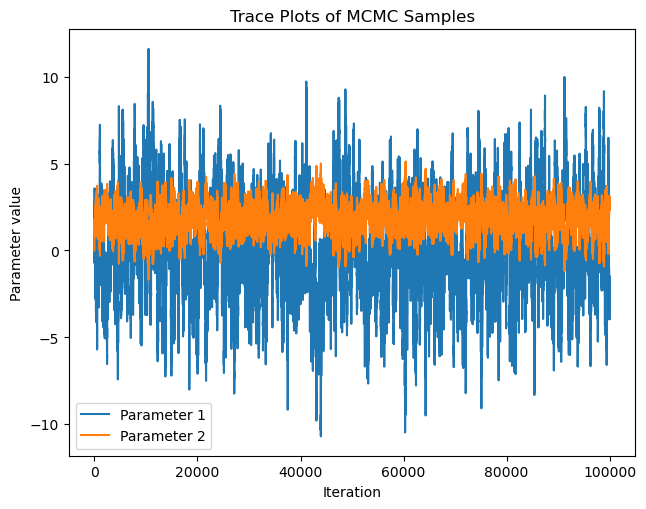

Estimated burn-in period: 5687 samples
Posterior Mean:
 [0.15324196 1.80879051]
Posterior Covariance:
 [[ 8.51889202 -2.38903154]
 [-2.38903154  0.7172653 ]]
Sampled Mean:
 [0.11515838 1.81934079]
Sampled Covariance:
 [[ 8.40576233 -2.35921643]
 [-2.35921643  0.70940421]]
Sampled Mean after Burn-in:
 [0.11576431 1.8191929 ]
Sampled Covariance after Burn-in:
 [[ 8.45371899 -2.37291807]
 [-2.37291807  0.71318141]]


In [84]:
# Define prior mean and covariance
m0 = np.array([0, 0])
Sigma0 = np.array([[10, 0], [0, 10]])
# Define the noise
#---------------------------------------------------------------------------
# Here we set the noise level to 1
#---------------------------------------------------------------------------
Gamma = np.diag(1 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 2))
A[:, 0] = 1
A[:, 1] = np.log(h)
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean = m0 + Sigma0 @ A.T @ np.linalg.inv(Gamma + A @ Sigma0 @ A.T) @ (y - A @ m0)
posterior_cov = Sigma0 - Sigma0 @ A.T @ np.linalg.inv(Gamma + A @ Sigma0 @ A.T) @ A @ Sigma0

n = 2  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
#--------------------------------------------------------------------------
# Tried out several 
#--------------------------------------------------------------------------
prop_var = 0.4  # optimal scaling for proposal variance

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples')
plt.legend()
plt.show()

sampled_mean = np.mean(samples, axis=0)
sampled_cov = np.cov(samples, rowvar=False)

# Burn in period
burn_in = estimate_burnin(samples)
print(f"Estimated burn-in period: {burn_in} samples")
samples = samples[burn_in:, :]

sampled_mean_burned = np.mean(samples, axis=0)
sampled_cov_burned = np.cov(samples, rowvar=False)
# Print the results
print("Posterior Mean:\n", posterior_mean)
print("Posterior Covariance:\n", posterior_cov)
print("Sampled Mean:\n", sampled_mean)
print("Sampled Covariance:\n", sampled_cov)
print("Sampled Mean after Burn-in:\n", sampled_mean_burned)
print("Sampled Covariance after Burn-in:\n", sampled_cov_burned)

The noise is clearly visible in our samples. We do not get any clear sample drawn from our target distribution. We have a large burn in period and do not estimate well the true parameters. Moreover, Our covariance matrix shows high covariances and variances. Everything is "unstable" and the result quiet useless. Even the high proposal variance of 0.4 did not save the outcome.

Second case: Noise level of 0.001

Here the outcome strongly depends on our prior beliefs due to the Bayesian. We expect a short burn in period. As we have a small noise level, uncertainties are not impacting the RWMA and our proposal variance can be rather small as this approach again amplifies our beliefs. Following this reasoning, too high proposal variances might lead to too small acceptance rates. Nevertheless, choosing such a small noise level might not be optimal as we do not  really explore but exploit based on our prior beliefs which might be wrong. The missing exploration might lead to a worse result.

Acceptance rate: 0.156000


C:\Users\adrie\AppData\Local\Temp\ipykernel_1924\146645463.py:24: RuntimeWarning: overflow encountered in exp
  accpt_prob = np.exp(log_accpt_prob)


Acceptance rate: 0.152500
Acceptance rate: 0.146333
Acceptance rate: 0.142500
Acceptance rate: 0.142400
Acceptance rate: 0.139667
Acceptance rate: 0.140143
Acceptance rate: 0.140375
Acceptance rate: 0.140778
Acceptance rate: 0.140700
Acceptance rate: 0.139818
Acceptance rate: 0.139417
Acceptance rate: 0.140077
Acceptance rate: 0.139714
Acceptance rate: 0.138067
Acceptance rate: 0.137063
Acceptance rate: 0.136941
Acceptance rate: 0.137278
Acceptance rate: 0.136526
Acceptance rate: 0.137050
Acceptance rate: 0.136857
Acceptance rate: 0.136909
Acceptance rate: 0.137043
Acceptance rate: 0.136375
Acceptance rate: 0.136680
Acceptance rate: 0.136538
Acceptance rate: 0.136444
Acceptance rate: 0.136679
Acceptance rate: 0.136345
Acceptance rate: 0.136067
Acceptance rate: 0.135806
Acceptance rate: 0.135719
Acceptance rate: 0.135879
Acceptance rate: 0.136118
Acceptance rate: 0.136229
Acceptance rate: 0.136250
Acceptance rate: 0.136027
Acceptance rate: 0.136368
Acceptance rate: 0.136154
Acceptance r

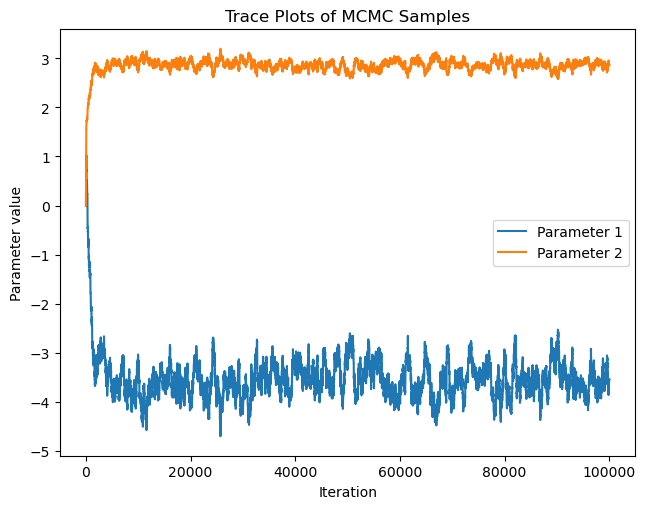

Estimated burn-in period: 2000 samples
Posterior Mean:
 [-3.55881846  2.86332418]
Posterior Covariance:
 [[ 0.1042523  -0.0293752 ]
 [-0.0293752   0.00832457]]
Sampled Mean:
 [-3.52655908  2.85366005]
Sampled Covariance:
 [[ 0.20049946 -0.05878459]
 [-0.05878459  0.01798814]]
Sampled Mean after Burn-in:
 [-3.56007377  2.86369062]
Sampled Covariance after Burn-in:
 [[ 0.11064731 -0.03119582]
 [-0.03119582  0.00884226]]


In [85]:
# Define prior mean and covariance
m0 = np.array([0, 0])
Sigma0 = np.array([[10, 0], [0, 10]])
# Define the noise
#---------------------------------------------------------------------------
# Here we set the noise level to 0.001
#---------------------------------------------------------------------------
Gamma = np.diag(0.001 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 2))
A[:, 0] = 1
A[:, 1] = np.log(h)
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean, posterior_cov = posterior(m0, Sigma0, A, Gamma, y)

n = 2  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
#--------------------------------------------------------------------------
# Tried out several 
#--------------------------------------------------------------------------
prop_var = 0.06**2  # optimal scaling for proposal variance

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples')
plt.legend()
plt.show()

sampled_mean = np.mean(samples, axis=0)
sampled_cov = np.cov(samples, rowvar=False)

burn_in = 2000
print(f"Estimated burn-in period: {burn_in} samples")
samples = samples[burn_in:, :]

sampled_mean_burned = np.mean(samples, axis=0)
sampled_cov_burned = np.cov(samples, rowvar=False)
# Print the results
print("Posterior Mean:\n", posterior_mean)
print("Posterior Covariance:\n", posterior_cov)
print("Sampled Mean:\n", sampled_mean)
print("Sampled Covariance:\n", sampled_cov)
print("Sampled Mean after Burn-in:\n", sampled_mean_burned)
print("Sampled Covariance after Burn-in:\n", sampled_cov_burned)

This plot shows nicely the small burn in period as expected. Our proposal variance is $0.06^2$

# Varying the proposal variance
Next, we set the noise level constant to 0.6 and vary the proposal variance. 
We will first set a small variance around $0.01^2$ and the a high one with 9. The impact is expected to be drastic. The proposal variance determines how large the symmetric proposal distribution is or more precisely how concentrated the probability mass is around the mean. That is, a small variance describes a narrow Gaussian and a larger variance stands for a "wide" Gaussian. Hence, higher variances imply a wider range of samples drawn from the proposal distribution, implying a larger range of X' in our RWMA. One could roughly say that the larger the variance the higher the uncertainty and the higher the "exploration".

Acceptance rate: 0.873000
Acceptance rate: 0.913500
Acceptance rate: 0.934667
Acceptance rate: 0.947750
Acceptance rate: 0.954200
Acceptance rate: 0.958667
Acceptance rate: 0.960571
Acceptance rate: 0.961125
Acceptance rate: 0.960778
Acceptance rate: 0.962000
Acceptance rate: 0.964182
Acceptance rate: 0.965417
Acceptance rate: 0.966615
Acceptance rate: 0.968071
Acceptance rate: 0.969400
Acceptance rate: 0.970375
Acceptance rate: 0.970412
Acceptance rate: 0.970556
Acceptance rate: 0.970947
Acceptance rate: 0.971050
Acceptance rate: 0.971667
Acceptance rate: 0.972000
Acceptance rate: 0.972957
Acceptance rate: 0.973625
Acceptance rate: 0.974160
Acceptance rate: 0.974577
Acceptance rate: 0.974222
Acceptance rate: 0.974429
Acceptance rate: 0.974793
Acceptance rate: 0.975200
Acceptance rate: 0.975645
Acceptance rate: 0.976000
Acceptance rate: 0.976061
Acceptance rate: 0.976441
Acceptance rate: 0.976657
Acceptance rate: 0.976500
Acceptance rate: 0.976838
Acceptance rate: 0.977105
Acceptance r

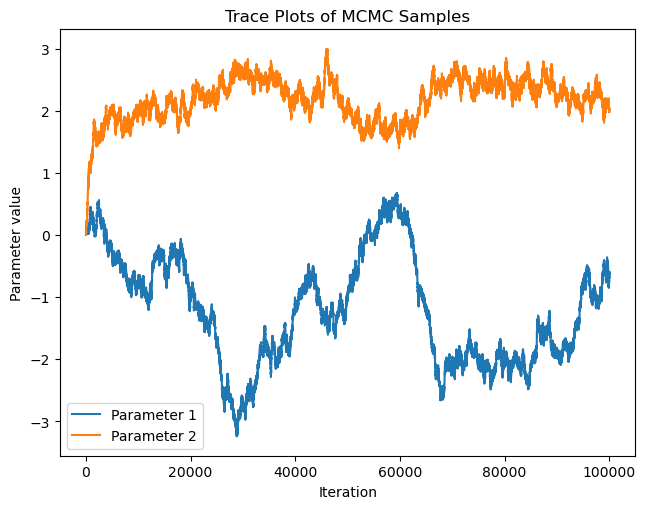

Posterior Mean:
 [-0.03803076  1.86596032]
Posterior Covariance:
 [[ 8.08251174 -2.27094886]
 [-2.27094886  0.6664961 ]]
Sampled Mean:
 [-1.21725624  2.17781792]
Sampled Covariance:
 [[ 0.77113879 -0.23826518]
 [-0.23826518  0.11512056]]


In [86]:
# Define prior mean and covariance
m0 = np.array([0, 0])
Sigma0 = np.array([[10, 0], [0, 10]])
# Define the noise
Gamma = np.diag(0.6 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 2))
A[:, 0] = 1
A[:, 1] = np.log(h)
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean , posterior_cov = posterior(m0, Sigma0, A, Gamma, y)

n = 2  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
prop_var = 0.01**2  # optimal scaling for proposal variance

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples')
plt.legend()
plt.show()

sampled_mean = np.mean(samples, axis=0)
sampled_cov = np.cov(samples, rowvar=False)
# Print the results
print("Posterior Mean:\n", posterior_mean)
print("Posterior Covariance:\n", posterior_cov)
print("Sampled Mean:\n", sampled_mean)
print("Sampled Covariance:\n", sampled_cov)

Acceptance rate: 0.064000
Acceptance rate: 0.059500
Acceptance rate: 0.058333
Acceptance rate: 0.057750
Acceptance rate: 0.058200
Acceptance rate: 0.056167
Acceptance rate: 0.056571
Acceptance rate: 0.056375
Acceptance rate: 0.058222
Acceptance rate: 0.058000
Acceptance rate: 0.057727
Acceptance rate: 0.057667
Acceptance rate: 0.056385
Acceptance rate: 0.056429
Acceptance rate: 0.055600
Acceptance rate: 0.054875
Acceptance rate: 0.054882
Acceptance rate: 0.055389
Acceptance rate: 0.056105
Acceptance rate: 0.055550
Acceptance rate: 0.055619
Acceptance rate: 0.055545
Acceptance rate: 0.055565
Acceptance rate: 0.055375
Acceptance rate: 0.055720
Acceptance rate: 0.055731
Acceptance rate: 0.056037
Acceptance rate: 0.056036
Acceptance rate: 0.055862
Acceptance rate: 0.055467
Acceptance rate: 0.055871
Acceptance rate: 0.056156
Acceptance rate: 0.056061
Acceptance rate: 0.056118
Acceptance rate: 0.056286
Acceptance rate: 0.056028
Acceptance rate: 0.056189
Acceptance rate: 0.056342
Acceptance r

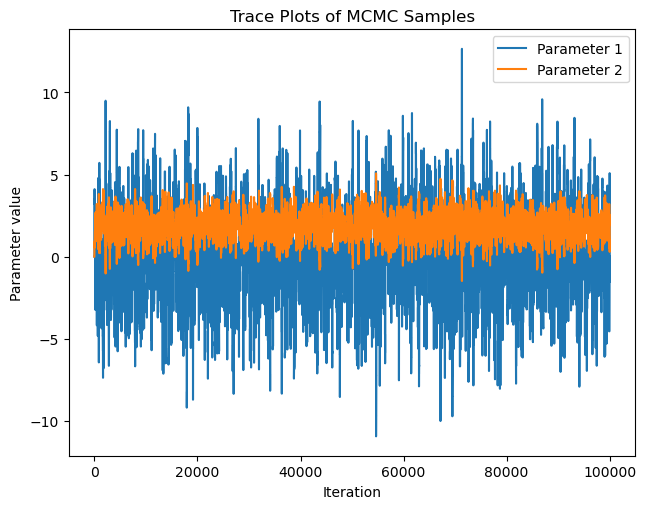

Posterior Mean:
 [-0.03803076  1.86596032]
Posterior Covariance:
 [[ 8.08251174 -2.27094886]
 [-2.27094886  0.6664961 ]]
Sampled Mean:
 [-0.05385545  1.86931973]
Sampled Covariance:
 [[ 8.18936213 -2.29786498]
 [-2.29786498  0.67264103]]


In [87]:
# Define prior mean and covariance
m0 = np.array([0, 0])
Sigma0 = np.array([[10, 0], [0, 10]])
# Define the noise
Gamma = np.diag(0.6 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 2))
A[:, 0] = 1
A[:, 1] = np.log(h)
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean , posterior_cov = posterior(m0, Sigma0, A, Gamma, y)

n = 2  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
prop_var = 9 # optimal scaling for proposal variance

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples')
plt.legend()
plt.show()

sampled_mean = np.mean(samples, axis=0)
sampled_cov = np.cov(samples, rowvar=False)
# Print the results
print("Posterior Mean:\n", posterior_mean)
print("Posterior Covariance:\n", posterior_cov)
print("Sampled Mean:\n", sampled_mean)
print("Sampled Covariance:\n", sampled_cov)

As expected, both results show that taking too extreme proposal variances yield bad outcomes in RWMA. In the case where we set our variance to $0.01^2$ we get an extremly high acceptance rate as uncertainty is reduced. However, our estimated mean and covariance are off.
In the case where we set our proposal variance to 9 we get too low acceptance rates as we emphasize uncertainty. However,probably due to our large amoint of amples (N = 1000000), the overall estimated posterior parameters are less off compared to the small variance case.

# A quadratic model
We finally consider the new model 
$$ \bold{q} = a + b\bold{h}+c\bold{h}^2+\eta$$
Assuming again an exponential shaped rating curve, we can reformulate this as $log(\bold{q})= A\bold{x}+\eta$ where our parameter vector is $\bold{x} = (a,b,c)^T$. The matrix A is given as 
$$ 
A =
\begin{pmatrix}
1 & h_1 & h_1^2\\
1 & h_2 & h_2^2 \\
\vdots & \vdots & \vdots \\
1 & h_{n_d} & h_{n_d}^2
\end{pmatrix}.
$$
We are asked to let the RWMA run with a proposal variance of $0.06^2$ and analyze the burn in period. Since we now have three parameters ($a, b, c$) instead of two, the proposal distribution becomes a $3 \times 3$ diagonal matrix. Usually, adding parameters requires a smaller $\sigma^2$ to maintain a stable acceptance rate, as the search space is higher-dimensional. Moreover, a more complex model with more parameters often requires a longer burn-in period because the Markov Chain may take longer to reach the high-probability region of the posterior distribution. So with this proposal variance we expect a small acceptance rate and a long burn-in period. We will also let it run with a much smaller proposal variance.

Acceptance rate: 0.011000
Acceptance rate: 0.007000
Acceptance rate: 0.005333
Acceptance rate: 0.004000
Acceptance rate: 0.003200
Acceptance rate: 0.002667
Acceptance rate: 0.002571
Acceptance rate: 0.002375
Acceptance rate: 0.002333
Acceptance rate: 0.002200
Acceptance rate: 0.002000
Acceptance rate: 0.001833
Acceptance rate: 0.001692
Acceptance rate: 0.001571
Acceptance rate: 0.001467
Acceptance rate: 0.001375
Acceptance rate: 0.001294
Acceptance rate: 0.001278
Acceptance rate: 0.001263
Acceptance rate: 0.001350
Acceptance rate: 0.001381
Acceptance rate: 0.001409
Acceptance rate: 0.001348
Acceptance rate: 0.001292
Acceptance rate: 0.001240
Acceptance rate: 0.001231
Acceptance rate: 0.001259
Acceptance rate: 0.001250
Acceptance rate: 0.001241
Acceptance rate: 0.001200
Acceptance rate: 0.001194
Acceptance rate: 0.001187
Acceptance rate: 0.001212
Acceptance rate: 0.001176
Acceptance rate: 0.001200
Acceptance rate: 0.001167
Acceptance rate: 0.001216
Acceptance rate: 0.001211
Acceptance r

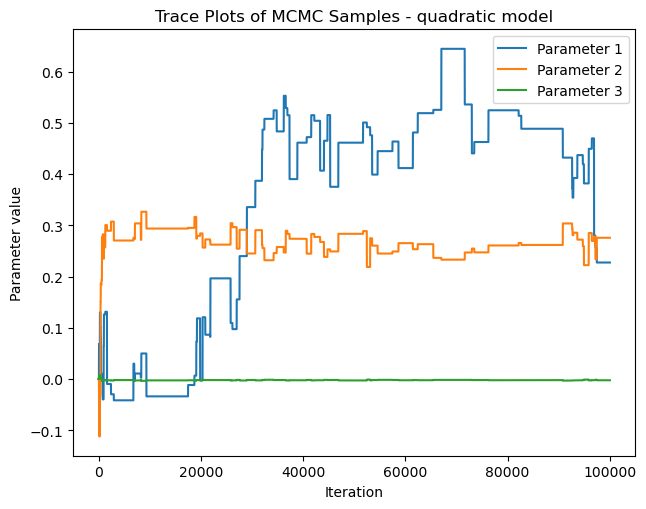

Estimated burn-in period: 85669 samples
Posterior Mean:
 [ 1.61180744e+00  1.97906230e-01 -1.53640045e-03]
Posterior Covariance:
 [[ 2.67174039e+00 -1.43532974e-01  1.79788737e-03]
 [-1.43532974e-01  7.93086417e-03 -1.01653792e-04]
 [ 1.79788732e-03 -1.01651778e-04  1.79818421e-06]]
Sampled Mean:
 [ 0.34494005  0.26576169 -0.00240009]
Sampled Covariance:
 [[ 4.44438651e-02 -2.26212962e-03  2.38602886e-05]
 [-2.26212962e-03  8.45177361e-04 -1.75730950e-05]
 [ 2.38602886e-05 -1.75730950e-05  4.08597288e-07]]


In [88]:
# Get height and flow from the data
q = data['Q'].values
h = data['H'].values
#---------------------------------------------------------------------------------------
# Adapt the prior to 3 parameters
#---------------------------------------------------------------------------------------
# Define prior mean and covariance
m0 = np.array([0, 0, 0])
Sigma0 = np.array([[10, 0, 0], [0, 10, 0], [0, 0, 10]])
# Define the noise
Gamma = np.diag(0.03 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 3))
A[:, 0] = 1
A[:, 1] = h
A[:,2] = h**2
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean_2d , posterior_cov_2d = posterior(m0, Sigma0, A, Gamma, y)

n = 3  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
prop_var = 0.06**2  # optimal scaling for proposal variance 

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples_2d = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples_2d[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples_2d[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.plot(range(1, N+1), samples_2d[:, 2], label='Parameter 3')
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples - quadratic model')
plt.legend()
plt.show()

burn_in = estimate_burnin(samples_2d)
print(f"Estimated burn-in period: {burn_in} samples")

#comparaison:
sampled_mean_2d = np.mean(samples_2d, axis=0)
sampled_cov_2d = np.cov(samples_2d, rowvar=False)
print("Posterior Mean:\n", posterior_mean_2d)
print("Posterior Covariance:\n", posterior_cov_2d)
print("Sampled Mean:\n", sampled_mean_2d)
print("Sampled Covariance:\n", sampled_cov_2d)

We observe that our expectations are matched. We see that our sampled means and covariances are of. We have a too small acceptance rate and the trace plots show that random generation following a stationary distribution is not done at all (step functions). This is enhanced by the fact that the burn-in period is almost the total generation process. We also see that the last parameter is close to zero with almost zero variance, implying a small impact and a model missfit. 

Let's try to fix it by reducing the proposal variance to $0.001^2$.

Acceptance rate: 0.103000
Acceptance rate: 0.107500
Acceptance rate: 0.108667
Acceptance rate: 0.110500
Acceptance rate: 0.111200
Acceptance rate: 0.111667
Acceptance rate: 0.112571
Acceptance rate: 0.114000
Acceptance rate: 0.114111
Acceptance rate: 0.114200
Acceptance rate: 0.114545
Acceptance rate: 0.114000
Acceptance rate: 0.113846
Acceptance rate: 0.113714
Acceptance rate: 0.113467
Acceptance rate: 0.112250
Acceptance rate: 0.112294
Acceptance rate: 0.111944
Acceptance rate: 0.111053
Acceptance rate: 0.111900
Acceptance rate: 0.112381
Acceptance rate: 0.111909
Acceptance rate: 0.111348
Acceptance rate: 0.111708
Acceptance rate: 0.111880
Acceptance rate: 0.111462
Acceptance rate: 0.111481
Acceptance rate: 0.111821
Acceptance rate: 0.112034
Acceptance rate: 0.111700
Acceptance rate: 0.112032
Acceptance rate: 0.111625
Acceptance rate: 0.111697
Acceptance rate: 0.111824
Acceptance rate: 0.111743
Acceptance rate: 0.111694
Acceptance rate: 0.111919
Acceptance rate: 0.112421
Acceptance r

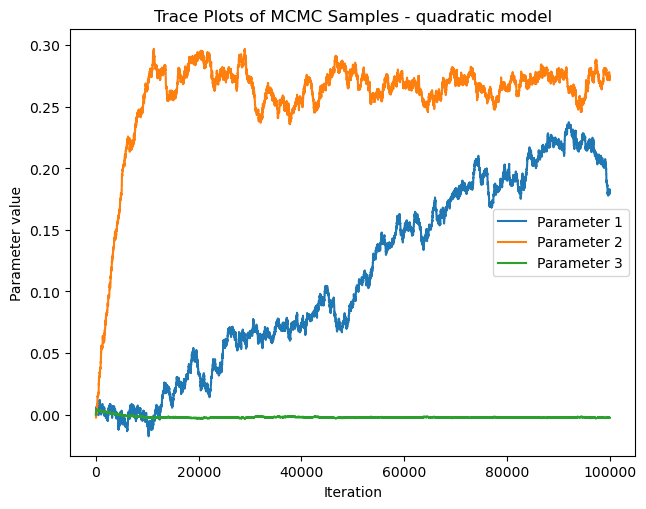

Estimated burn-in period: 91259 samples
Posterior Mean:
 [ 1.61180744e+00  1.97906230e-01 -1.53640045e-03]
Posterior Covariance:
 [[ 2.67174039e+00 -1.43532974e-01  1.79788737e-03]
 [-1.43532974e-01  7.93086417e-03 -1.01653792e-04]
 [ 1.79788732e-03 -1.01651778e-04  1.79818421e-06]]
Sampled Mean:
 [ 0.11128667  0.25814861 -0.00207392]
Sampled Covariance:
 [[ 5.72117047e-03  1.06066005e-03 -2.76956181e-05]
 [ 1.06066005e-03  1.70924450e-03 -4.00397725e-05]
 [-2.76956181e-05 -4.00397725e-05  9.47468588e-07]]


In [89]:
# Get height and flow from the data
q = data['Q'].values
h = data['H'].values
#---------------------------------------------------------------------------------------
# Adapt the prior to 3 parameters
#---------------------------------------------------------------------------------------
# Define prior mean and covariance
m0 = np.array([0, 0, 0])
Sigma0 = np.array([[10, 0, 0], [0, 10, 0], [0, 0, 10]])
# Define the noise
Gamma = np.diag(0.03 * np.maximum(np.log(q), 1e-6))
# Define the matrix A in our model
A = np.zeros((length, 3))
A[:, 0] = 1
A[:, 1] = h
A[:,2] = h**2
# Use log(q) as the observed data
y = np.log(q)
# Now we can compute the posterior mean and covariance
posterior_mean_2d , posterior_cov_2d = posterior(m0, Sigma0, A, Gamma, y)

n = 3  # dimension of the samples
N = 100000  # number of desired samples in the chain
x0 = np.zeros(n)  # starting point
prop_var = 0.001**2  # optimal scaling for proposal variance 

def proposal():
    return rnd.multivariate_normal(mean=np.zeros(n), cov=prop_var*np.eye(n))

samples_2d = RWMA(m0, Sigma0, q, A, Gamma, N, x0)

plt.figure()
plt.plot(range(1, N+1), samples_2d[:, 0], label='Parameter 1')  # plot first component of all chain elements
plt.plot(range(1, N+1), samples_2d[:, 1], label='Parameter 2')  # plot second component of all chain elements
plt.plot(range(1, N+1), samples_2d[:, 2], label='Parameter 3')
plt.tight_layout()
plt.xlabel('Iteration')
plt.ylabel('Parameter value')
plt.title('Trace Plots of MCMC Samples - quadratic model')
plt.legend()
plt.show()

burn_in = estimate_burnin(samples_2d)
print(f"Estimated burn-in period: {burn_in} samples")

#comparaison:
sampled_mean_2d = np.mean(samples_2d, axis=0)
sampled_cov_2d = np.cov(samples_2d, rowvar=False)
print("Posterior Mean:\n", posterior_mean_2d)
print("Posterior Covariance:\n", posterior_cov_2d)
print("Sampled Mean:\n", sampled_mean_2d)
print("Sampled Covariance:\n", sampled_cov_2d)

As expected, the smaller proposal variance led to a higher acceptance rate. The parameters are better approximated. However, we still observe that the last parameter doesn't vary at all and is close to zero, implying a model missspecification. Next, the burn in got reduced, however is still large, backing up the hypothesis that the Markov Chain may take longer to reach the high-probability region of the posterior distribution. Furthermore, the inconviences depicted before of a small proposal variance persist.

# Comparing both models
It is not surprising that the linear relation seems to work better.
First, a rating function is generally modelled by a (piecewise) smooth power function $ q = a(h-c)^n$ where $a, are calibration factors and $c$ is the average height for zero discharge$. Hence, mathematically speaking, applying the log will transform it to a linear fitting problem. Looking at the plot below where we plotted the log height against the log discharge confirms this. 
Second, the quadratic model introduces an additional parameter which leads to strong posterior correlations and poorer mixing of the RWMA. Although it is more flexible, it is less identifiable and less physically motivated than the log–linear rating curve model. It introduces unnecessary complexity and due to the requirement of a very small proposal variance, the key advantges of RWMA are not exploited. It is necessary to fine-tune the parameters of the RWMA as depicted in the previous paragraphs.

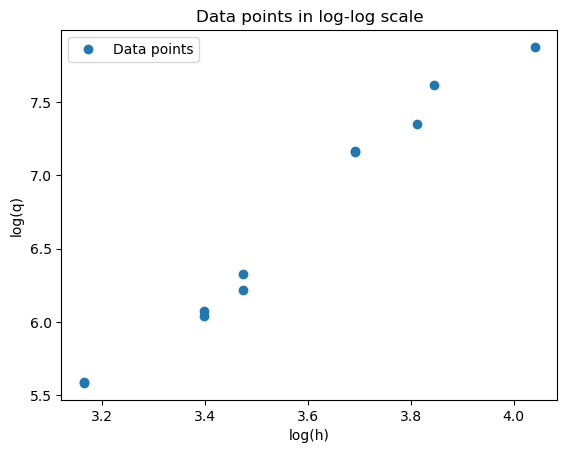

In [90]:
plt.figure()
plt.plot(np.log(h),np.log(q), 'o', label='Data points')
plt.legend()
plt.xlabel('log(h)')
plt.ylabel('log(q)')
plt.title('Data points in log-log scale')
plt.show()